In [1]:
import torch

print(torch.__version__)
print(torch.cuda.is_available())

2.8.0+cu128
True


In [2]:
dataset_location = "../../dataset/MSGOv2_small"

In [3]:
from rfdetr import RFDETRNano

model = RFDETRNano()

# batch_size * grad_accum_steps = 16
model.train(dataset_dir=dataset_location, epochs=2, batch_size=2, grad_accum_steps=8)  # , early_stopping=True)

Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
Loading pretrain weights


num_classes mismatch: model has 90 classes, but your dataset has 6 classes
reinitializing your detection head with 6 classes.


Unable to initialize TensorBoard. Logging is turned off for this session.  Run 'pip install tensorboard' to enable logging.
Not using distributed mode
git:
  sha: 41557023c28fb0c06f8b29afe63f53cf58d1dc4f, status: has uncommited changes, branch: develop

Namespace(num_classes=6, grad_accum_steps=8, amp=True, lr=0.0001, lr_encoder=0.00015, batch_size=2, weight_decay=0.0001, epochs=2, lr_drop=100, clip_max_norm=0.1, lr_vit_layer_decay=0.8, lr_component_decay=0.7, do_benchmark=False, dropout=0, drop_path=0.0, drop_mode='standard', drop_schedule='constant', cutoff_epoch=0, pretrained_encoder=None, pretrain_weights='rf-detr-nano.pth', pretrain_exclude_keys=None, pretrain_keys_modify_to_load=None, pretrained_distiller=None, encoder='dinov2_windowed_small', vit_encoder_num_layers=12, window_block_indexes=None, position_embedding='sine', out_feature_indexes=[3, 6, 9, 12], freeze_encoder=False, layer_norm=True, rms_norm=False, backbone_lora=False, force_no_pretrain=False, dec_layers=2, dim_feedf

Epoch: [0]  [0/6]  eta: 0:01:22  lr: 0.000100  class_error: 81.07  loss: 8.1907 (8.1907)  loss_ce: 0.6058 (0.6058)  loss_bbox: 0.6422 (0.6422)  loss_giou: 1.4118 (1.4118)  loss_ce_0: 0.5722 (0.5722)  loss_bbox_0: 0.6920 (0.6920)  loss_giou_0: 1.5059 (1.5059)  loss_ce_enc: 0.5584 (0.5584)  loss_bbox_enc: 0.7129 (0.7129)  loss_giou_enc: 1.4894 (1.4894)  loss_ce_unscaled: 0.6058 (0.6058)  class_error_unscaled: 81.0651 (81.0651)  loss_bbox_unscaled: 0.1284 (0.1284)  loss_giou_unscaled: 0.7059 (0.7059)  cardinality_error_unscaled: 1243.5000 (1243.5000)  loss_ce_0_unscaled: 0.5722 (0.5722)  loss_bbox_0_unscaled: 0.1384 (0.1384)  loss_giou_0_unscaled: 0.7530 (0.7530)  cardinality_error_0_unscaled: 1919.0000 (1919.0000)  loss_ce_enc_unscaled: 0.5584 (0.5584)  loss_bbox_enc_unscaled: 0.1426 (0.1426)  loss_giou_enc_unscaled: 0.7447 (0.7447)  cardinality_error_enc_unscaled: 3282.0000 (3282.0000)  time: 13.7906  data: 9.3477  max mem: 1581
Epoch: [0]  [5/6]  eta: 0:00:05  lr: 0.000100  class_error

Test:  [ 0/10]  eta: 0:01:34  class_error: 100.00  loss: 6.1068 (6.1068)  loss_ce: 1.2344 (1.2344)  loss_bbox: 0.5220 (0.5220)  loss_giou: 0.4152 (0.4152)  loss_ce_0: 1.2578 (1.2578)  loss_bbox_0: 0.4288 (0.4288)  loss_giou_0: 0.3789 (0.3789)  loss_ce_enc: 1.3438 (1.3438)  loss_bbox_enc: 0.2496 (0.2496)  loss_giou_enc: 0.2763 (0.2763)  loss_ce_unscaled: 1.2344 (1.2344)  class_error_unscaled: 100.0000 (100.0000)  loss_bbox_unscaled: 0.1044 (0.1044)  loss_giou_unscaled: 0.2076 (0.2076)  cardinality_error_unscaled: 113.5000 (113.5000)  loss_ce_0_unscaled: 1.2578 (1.2578)  loss_bbox_0_unscaled: 0.0858 (0.0858)  loss_giou_0_unscaled: 0.1894 (0.1894)  cardinality_error_0_unscaled: 104.0000 (104.0000)  loss_ce_enc_unscaled: 1.3438 (1.3438)  loss_bbox_enc_unscaled: 0.0499 (0.0499)  loss_giou_enc_unscaled: 0.1382 (0.1382)  cardinality_error_enc_unscaled: 253.0000 (253.0000)  time: 9.4611  data: 9.1140  max mem: 2177
Test:  [ 9/10]  eta: 0:00:01  class_error: 100.00  loss: 6.5092 (6.6493)  loss_

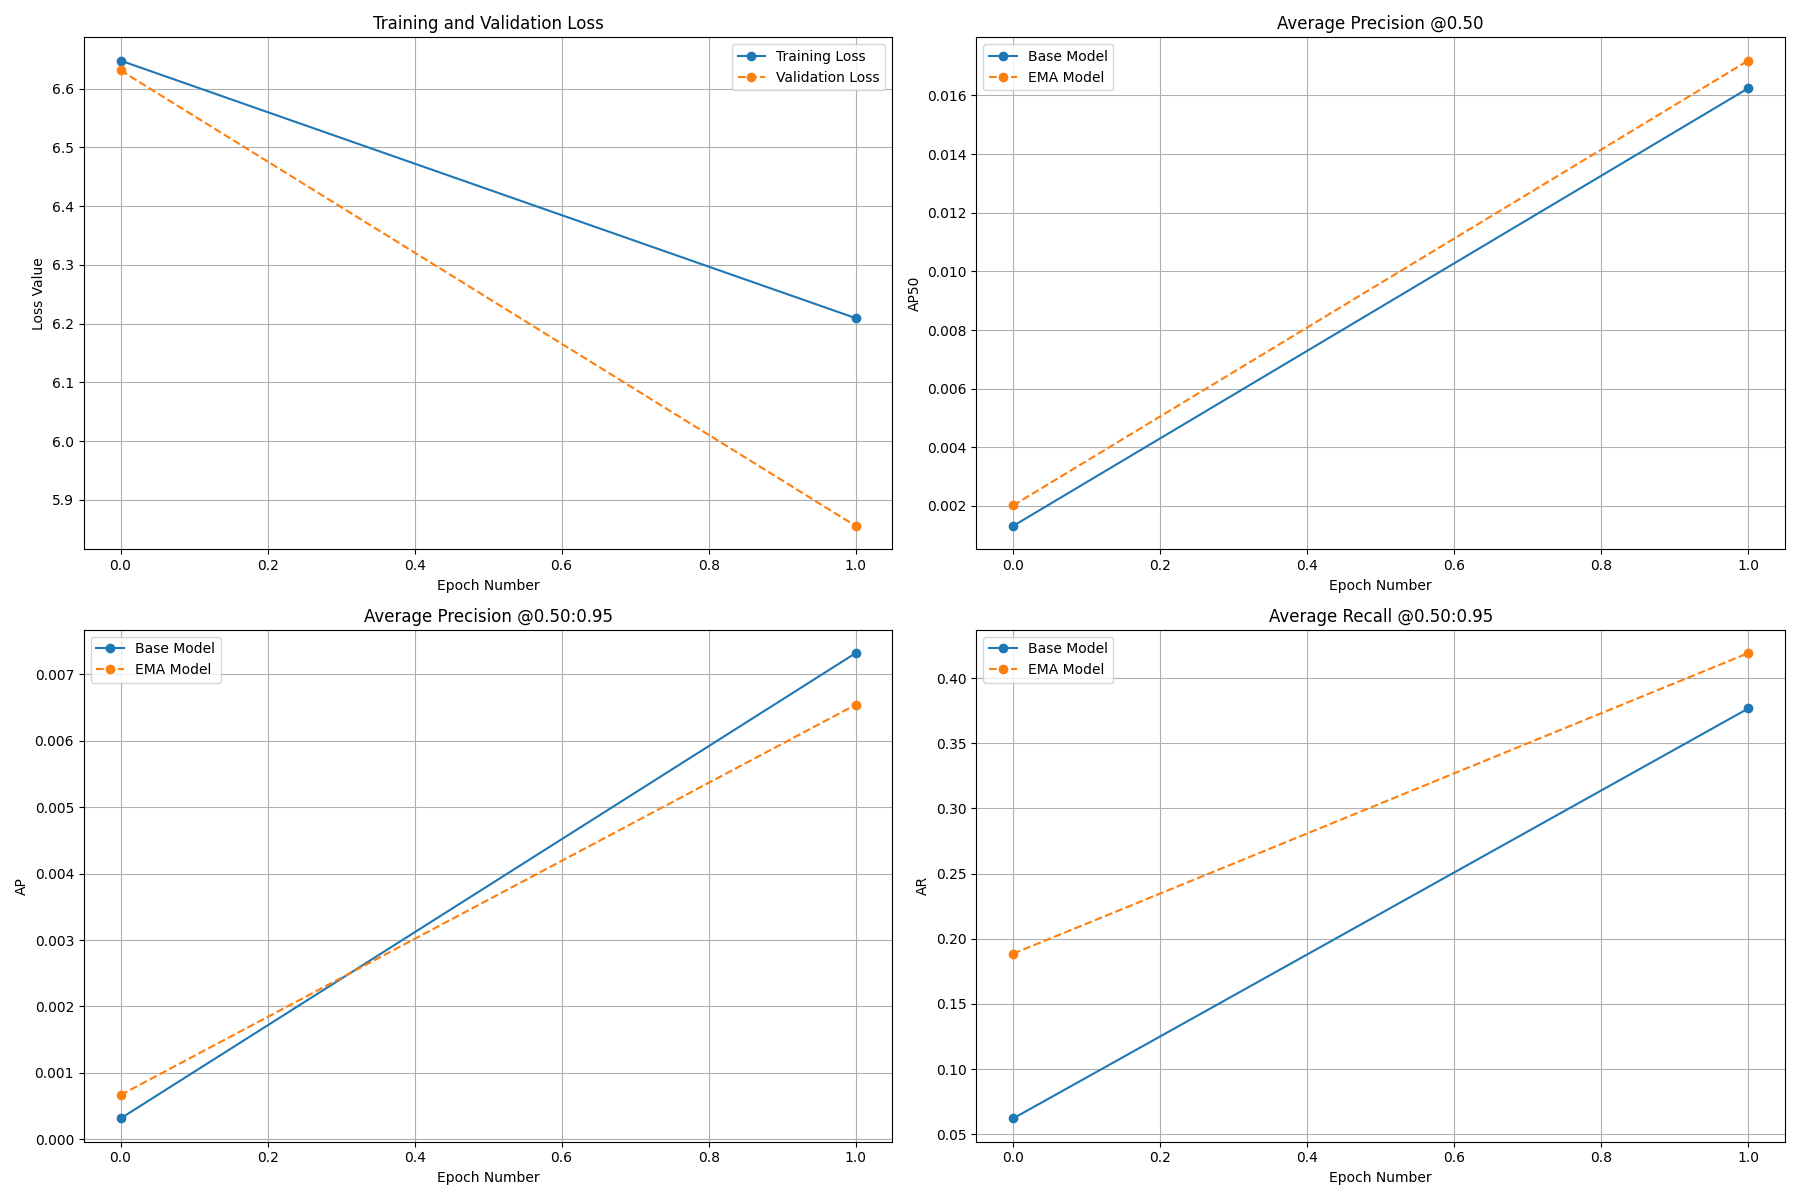

In [4]:
from PIL import Image

Image.open("output/metrics_plot.png")

In [5]:
import gc
import weakref

import torch


def cleanup_gpu_memory(obj=None, verbose: bool = False):
    if not torch.cuda.is_available():
        if verbose:
            print("[INFO] CUDA is not available. No GPU cleanup needed.")
        return

    def get_memory_stats():
        allocated = torch.cuda.memory_allocated()
        reserved = torch.cuda.memory_reserved()
        return allocated, reserved

    torch.cuda.synchronize()

    if verbose:
        alloc, reserv = get_memory_stats()
        print(f"[Before] Allocated: {alloc / 1024**2:.2f} MB | Reserved: {reserv / 1024**2:.2f} MB")

    # Ensure we drop all strong references
    if obj is not None:
        ref = weakref.ref(obj)
        del obj
        if ref() is not None and verbose:
            print("[WARNING] Object not fully garbage collected yet.")

    gc.collect()
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()

    torch.cuda.synchronize()

    if verbose:
        alloc, reserv = get_memory_stats()
        print(f"[After]  Allocated: {alloc / 1024**2:.2f} MB | Reserved: {reserv / 1024**2:.2f} MB")

In [6]:
cleanup_gpu_memory(model, verbose=True)

[Before] Allocated: 247.78 MB | Reserved: 2476.00 MB
[WARNING] Object not fully garbage collected yet.
[After]  Allocated: 247.78 MB | Reserved: 280.00 MB


In [7]:
model = RFDETRNano(pretrain_weights="output/checkpoint_best_total.pth")
model.optimize_for_inference()

Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.


num_classes mismatch: pretrain weights has 5 classes, but your model has 90 classes
reinitializing detection head with 5 classes


Loading pretrain weights


`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


In [8]:
import supervision as sv

ds = sv.DetectionDataset.from_coco(
    images_directory_path=f"{dataset_location}\\test",
    annotations_path=f"{dataset_location}\\test\\_annotations.coco.json",
)

In [9]:
from supervision.metrics import MeanAveragePrecision
from tqdm import tqdm

targets = []
predictions = []

for path, _, annotations in tqdm(ds):
    image = Image.open(path)
    detections = model.predict(image, threshold=0)

    targets.append(annotations)
    predictions.append(detections)

100%|██████████| 20/20 [00:06<00:00,  3.24it/s]


In [10]:
map_metric = MeanAveragePrecision()
map_result = map_metric.update(predictions, targets).compute()
print(map_result)

Average Precision (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.005
Average Precision (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.010
Average Precision (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.003
Average Precision (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.000
Average Precision (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ]                 = 0.001
Average Precision (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ]                 = 0.018


In [11]:
class_names = ds.classes
per_class_results = {}

for class_id, class_name in enumerate(class_names):
    map_metric = MeanAveragePrecision()

    class_targets = []
    class_predictions = []

    for i in range(len(predictions)):
        target_annotations = targets[i]
        class_targets.append(target_annotations[target_annotations.class_id == class_id])
        prediction_detections = predictions[i]
        class_predictions.append(prediction_detections[prediction_detections.class_id == class_id])

    map_result = map_metric.update(class_predictions, class_targets).compute()

    per_class_results[class_name] = {"mAP@50": map_result.map50, "mAP@50-95": map_result.map50_95}

print(f"{'Class':<20} | {'mAP@50':<10} | {'mAP@50-95':<10}")

for class_name, metrics in per_class_results.items():
    map50 = metrics["mAP@50"]
    map50_95 = metrics["mAP@50-95"]
    print(f"{class_name:<20} | {map50:<10.3f} | {map50_95:<10.3f}")

map_metric_all = MeanAveragePrecision()
map_result_all = map_metric_all.update(predictions, targets).compute()
map50_all = map_result_all.map50
map50_95_all = map_result_all.map50_95
print(f"{'all':<20} | {map50_all:<10.3f} | {map50_95_all:<10.3f}")

Class                | mAP@50     | mAP@50-95 
Plane                | 0.021      | 0.009     
Bridge               | 0.000      | 0.000     
Intersection         | -1.000     | -1.000    
Roundabout           | -1.000     | -1.000    
Vehicle              | 0.008      | 0.004     
Ship                 | 0.011      | 0.006     
all                  | 0.010      | 0.005     
